## **Duffing oscillator**



## **I. Setup and Preprocessing**

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

[5.48357077 2.30867849]
Guess highest order polynomial: 3


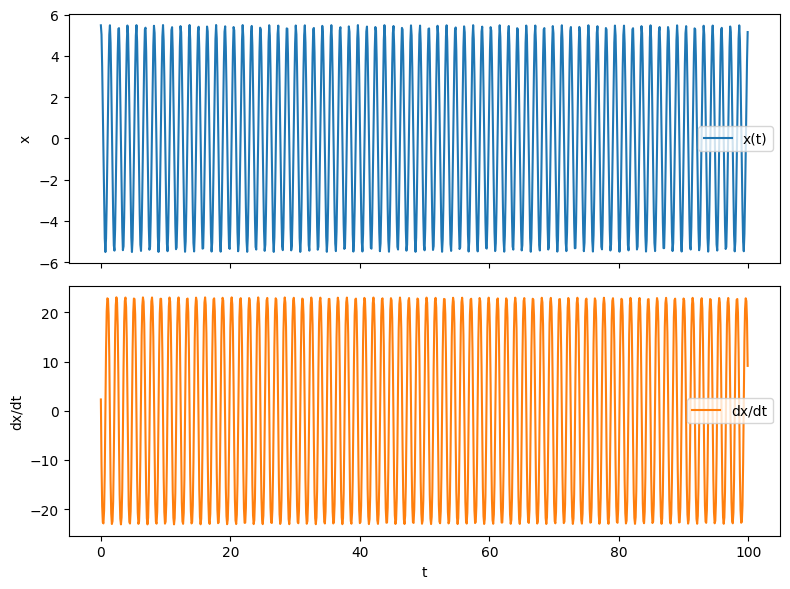

Training input shape: (1000, 2)
Training output shape: (1000, 2)


In [2]:
# Specify the model type
MY_MODEL = 'duffing'

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

# Generate data based on the specified model type
num_traj = 1
data_initial_conditions = []
for i in range(num_traj):
    x0 = np.random.normal(3, 5.0, size=2)  # [x, dx/dt]
    data_initial_conditions.append(x0)

print(data_initial_conditions[0])

data_T = 100.0       # Length of the data (T)
data_dt = 0.1     # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions, T=data_T, dt=data_dt, random_state=SEED)
p=[0.0001,10, 0.5]
t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(
    MY_MODEL, p, method='DOP853')


print("Guess highest order polynomial:", guess_highest_order_polynomial)

# Plot response for the first trajectory
import matplotlib.pyplot as plt

steps = t_arr.shape[0]
t_plot = t_arr.squeeze()
x_first = x_train[:steps, 0]
xdot_first = x_train[:steps, 1]

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t_plot, x_first,label='x(t)')
ax[0].set_ylabel('x')
ax[0].legend()
ax[1].plot(t_plot, xdot_first, label='dx/dt', color='tab:orange')
ax[1].set_ylabel('dx/dt')
ax[1].set_xlabel('t')
ax[1].legend()
plt.tight_layout()
plt.show()

# Shuffle data
training_input, training_output = x_train, dx_train

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)


### **1.3 Hyperparameters**



In [3]:
# Set mini-batch size
MINI_BATCH_SIZE = 32
learning_rate = 0.01

### **1.4 Model Architecture Definitions**

**SREINet Parameters**


In [4]:
# Assign dim to be the 2nd dimension of the training data (number of input variables, including the added constant 1)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_depth = guess_highest_order_polynomial
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # excluding the constant term; NOT the total number of neurons per layer

[2, 2, 2]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [5]:
activation_fns = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-4, seed=SEED),
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)


### **2.2 Loss Function**

In [6]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)
 
from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [7]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 trainer**


In [8]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**


#### **Pruning Profile**


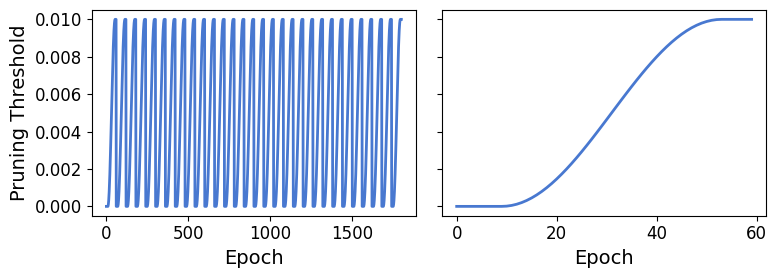

In [9]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.01 #.3-.35 
N_PERIODS = 30
PRUNING_EPOCHS_PER_PERIOD = 60
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.15,
                    show_plot=True)


In [10]:
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.0001

training_histories = []
weights_list = []
loss_list = []


In [11]:
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(0,training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     patience_periods=15,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

Total Dimensions: 2
Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 7.302e+01,  Validation Loss: 1.862e+01,  Epoch Time: 0.22s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 4.524e+00,  Validation Loss: 7.037e-01,  Epoch Time: 0.02s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 5.768e-01,  Validation Loss: 4.535e-01,  Epoch Time: 0.02s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 2.766e-01,  Validation Loss: 3.030e-01,  Epoch Time: 0.02s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 2.458e-01,  Validation Loss: 2.653e-01,  Epoch Time: 0.02s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 2.667e-01,  Validation Loss: 2.911e-01,  Epoch Time: 0.02s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 3.118e-01,  Validation Loss: 3.631e-01,  Epoch Time: 0.02s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 2.635e-01,  Validation Loss: 2.575e-01,  Epoch

## **IV. Coefficient Reconstructor (SREINet)**



#### `generate_set_labels`

In [12]:
def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

def generate_layer_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

#### `coefficient_reconstruction`


In [13]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results Display**
### **Identified Model**

In [14]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-5,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 0.9999998589*x2
(x2)' =  - 10.00000008*x1 - 9.995446017e-05*x2 - 0.500000112*x1^3


### **Validation**


In [15]:
import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str);
recovered_model.export_equations()
print(recovered_model.variables)

{'x1', 'x2'}


### Comparing vector field

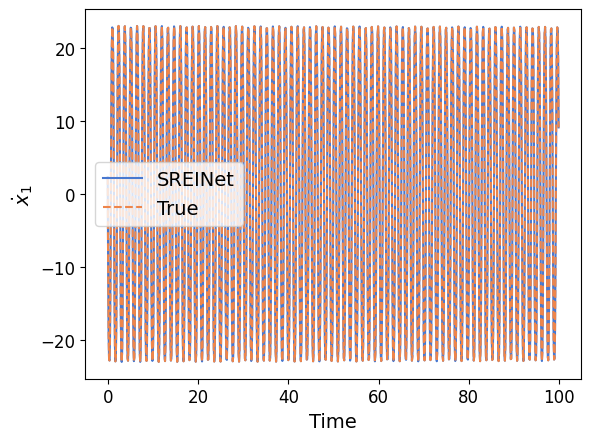

In [16]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()


### Comparing response

In [17]:
val_t_span = [0,50]
val_t_eval = np.arange(0,50,data_dt)

validation_result = recovered_model.simulate(data_initial_conditions[0], t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

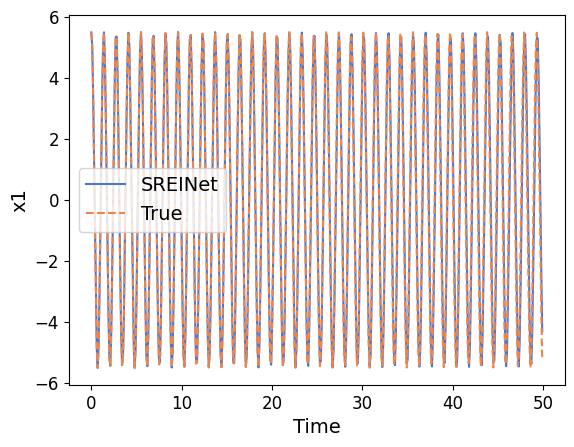

In [18]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()

